## Importy

In [32]:
import sys, os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torchvision import datasets
from torch import nn
from torch.nn import functional as F

# Funkcje pomocnicze

In [33]:
def wizualizuj_mnist(digit_indices, data, rng):
  fig, ax = plt.subplots(figsize=(10,10), nrows=10,ncols=10)
  for i in range(10):
    # Losowo wybierz 10 indeksów dla bieżącej cyfry
    selected_indices = rng.choice(digit_indices[i], size=10, replace=False)
    for j in range(10):
      image, label = data[selected_indices[j]]
      ax[i,j].imshow(image.squeeze(), cmap="gray")
      ax[i,j].set_title(f"Label: {label}")
      ax[i,j].axis("off")
  plt.tight_layout()
  plt.show()
  
def pokaz_rekonstrukcje(model, train_data, digit_indices, rng, device, rows=10, cols=10):
    """
    Wizualizuje zrekonstruowane obrazy z modelu.

    Args:
        model: Model VAE
        train_data: Zbiór treningowy
        digit_indices: Lista indeksów dla każdej cyfry
        rng: Generator liczb losowych
        device: Urządzenie do uruchamiania modelu
        rows: Liczba wierszy na wykresie
        cols: Liczba kolumn na wykresie
    """
    fig, ax = plt.subplots(figsize=(10,10), nrows=rows, ncols=cols)
    for i in range(rows):
        selected_indices = rng.choice(digit_indices[i], size=cols, replace=False)
        for j in range(cols):
            image, label = train_data[selected_indices[j]]
            image = image.to(device)
            with torch.no_grad():
                recon, mu, logvar = model(image)

            ax[i,j].imshow(recon.detach().cpu().squeeze().reshape(28,28), cmap="gray")
            ax[i,j].set_title(f"Label: {label}")
            ax[i,j].axis("off")
    plt.tight_layout()
    plt.show()


def extract_latent_representations(model, dataloader, device):
    """
    Wyodrębnia reprezentacje latentne (mu) ze wszystkich danych.

    Args:
        model: Model VAE
        dataloader: Loader danych
        device: Urządzenie do obliczeń

    Returns:
        mu_list: Połączone wartości mu jako tensor
        labels: Połączone etykiety jako tablica numpy
    """
    mu_list = []
    labels = []

    with torch.no_grad():
        for i, (data, label) in enumerate(dataloader):
            data = data.to(device)
            recon_batch, mu, logvar = model(data)
            mu_list.append(mu.cpu().detach())
            labels.append(label)

    mu_list = torch.cat(mu_list, dim=0)
    labels = torch.cat(labels, dim=0).numpy()

    return mu_list, labels


def plot_latent_space(mu_list, labels, title='Scatter Plot of Mu Values', xlabel='Dimension 1', ylabel='Dimension 2'):
    """
    Rysuje reprezentacje przestrzeni latentnej.

    Args:
        mu_list: Reprezentacje latentne (tensor/tablica Nx2 lub NxD)
        labels: Etykiety dla każdego punktu
        title: Tytuł wykresu
        xlabel: Etykieta osi X
        ylabel: Etykieta osi Y
    """
    plt.figure(figsize=(10, 10))

    # Konwertuj na numpy jeśli jest tensorem
    if torch.is_tensor(mu_list):
        mu_np = mu_list.numpy()
    else:
        mu_np = mu_list

    # Rysuj każdą cyfrę innym kolorem
    for i in range(10):
        plt.scatter(mu_np[labels == i, 0], mu_np[labels == i, 1], label=i)

    plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

# Intro: Redukcja wymiarowości i przestrzeń latentna

W uczeniu maszynowym często pracujemy z danymi o bardzo wysokiej wymiarowości (np. obrazy 28x28 pikseli = 784 wymiary). Redukcja wymiarowości pozwala nam zmniejszyć liczbę cech zachowując przy tym najważniejsze informacje, co ma kilka kluczowych zalet: przyspiesza trenowanie modeli, redukuje zużycie pamięci, ułatwia wizualizację danych i może pomóc w uniknięciu przeuczenia (overfitting).

Do redukcji wymiarowości można wykorzystać klasyczne metody statystyczne jak **PCA (Principal Component Analysis)**, która znajduje liniowe kombinacje cech o największej wariancji, lub **UMAP (Uniform Manifold Approximation and Projection)**, która lepiej zachowuje nieliniowe struktury danych.

Alternatywnym podejściem są **autoencodery** - sieci neuronowe, które uczą się kompresować dane do niższej wymiarowości (przestrzeń latentna) i następnie je rekonstruować. W przeciwieństwie do PCA, autoencodery mogą uczyć się nieliniowych reprezentacji dostosowanych do konkretnego typu danych. **Wariacyjne autoencodery (VAE)** idą krok dalej, ucząc się nie tylko kompresji, ale także probabilistycznej struktury przestrzeni latentnej, co pozwala na generowanie nowych przykładów.

Niskowymiarowe reprezentacje są szczególnie przydatne do **eksploracji i analizy struktury danych**. Rzutując dane na 2 lub 3 wymiary możemy wizualnie ocenić czy i jak dane grupują się w klastry, odkryć naturalne podziały w zbiorze, zidentyfikować wartości odstające czy zrozumieć relacje między różnymi klasami. Taka wizualna inspekcja często ujawnia nieoczywiste wzorce i pomaga w debugowaniu modeli uczenia maszynowego.

Będziemy pracować na zbiorze MNIST, czyli zbiorze czarno-białych obrazków z ręcznie napisanymi cyframi.

## Przygotowanie środowiska programistycznego

By zapewnić powtarzalność wyników ustawiany ziarno generatora liczb losowych:
```Python
seed = 128
rng = np.random.RandomState(seed)
```

In [34]:
seed = 128
rng = np.random.default_rng(seed=seed)

Tak jak na poprzednich zajęciach - ustalamy na jakim urządzeniu liczymy (gpu/cpu) i jaki format danych chcemy wykorzystać. Dla komputerów z apple silicon odpowiedni device to mps.

In [35]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
dtype = torch.float32

Using device: mps


## Import danych MNIST

In [36]:
train_data = datasets.MNIST(
    root='./data/', # Lokalizacja do przechowania danych
    train=True, # chcemy zbiór treningowy
    download=True, # jeżeli jeszcze nie są pobrane, to pobieramy
    transform=transforms.ToTensor(), # zdjęcia przekształcamy do tensorów. Uwaga! transformacja automatycznie skaluje obrazki do [0,1]!
    target_transform=None # możesz również transformować etykiety
)
# Przygotowanie danych testowych
test_data = datasets.MNIST(
    root='./data/',
    train=False, # jak nie chcemy zbioru treningowego, to znaczy że chcemy testowy
    download=True,
    transform=transforms.ToTensor()
)

# Wizualizacja oryginalnego zbioru danych

Przygotujmy listę indeksów poszczególnych cyfr

In [37]:
digit_indices = [[] for _ in range(10)]
for i in range(len(train_data)):
    _, label = train_data[i]
    digit_indices[label].append(i)

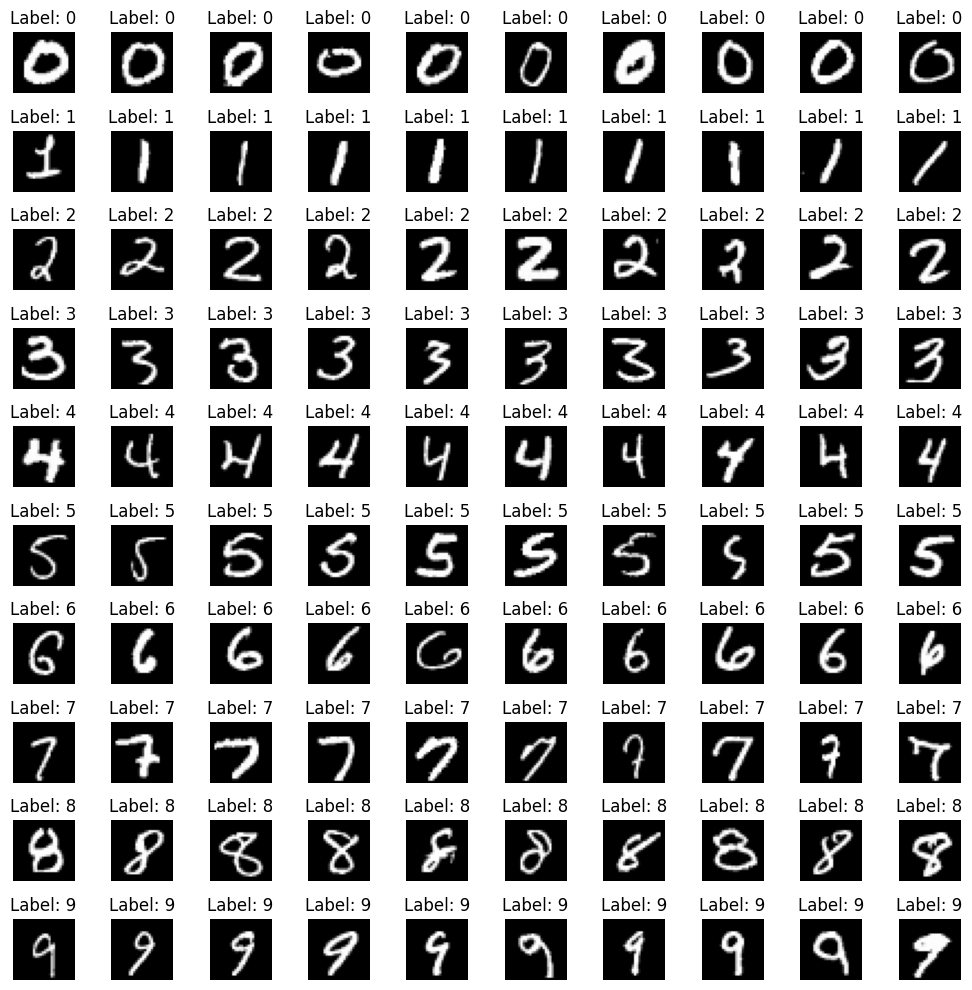

In [38]:
wizualizuj_mnist(digit_indices = digit_indices, data= train_data, rng=rng)

## Tworzymy dataloadery

In [39]:
BATCH_SIZE = 512 # Określa ile przykładów  będzie w jednej paczce (batchu), na podstawie której model będzie aktualizował swoje wagi

train_dataloader = DataLoader(train_data,
    batch_size=BATCH_SIZE,
    shuffle=True # Zawsze trzeba pamiętać aby podczas treningu model dostawał próbki w losowej kolejności, to może mieć duży wpływ na jakość treningu.
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # Przy ewaluacji modelu to nie ma znaczenia, więc nie warto na to tracić czasu.
)

# Na początek klasycznie: PCA
Obrazki w zbiorze MNIST mają wymiar 28x28. Jeśli potraktujemy je jako wektory 28*28 = 768 wymiarowe to za pomocą PCA możemy znaleźć kierunki w tej przestrzeni, które tłumaczą kolejno malejącą ilość wariancji tych wektorów. Sprawdźmy jak szybko tłumaczono jest wariancja - wykres osypiska (wartości własne w funkcji indeksu komponentu) oraz jak wygląda scatter plot naszych danych jeśli by  ogranizczyć się tylko do 2 pierwszych komponentów. Skorzystamy z implementacji PCA dostępnej w sklearn.

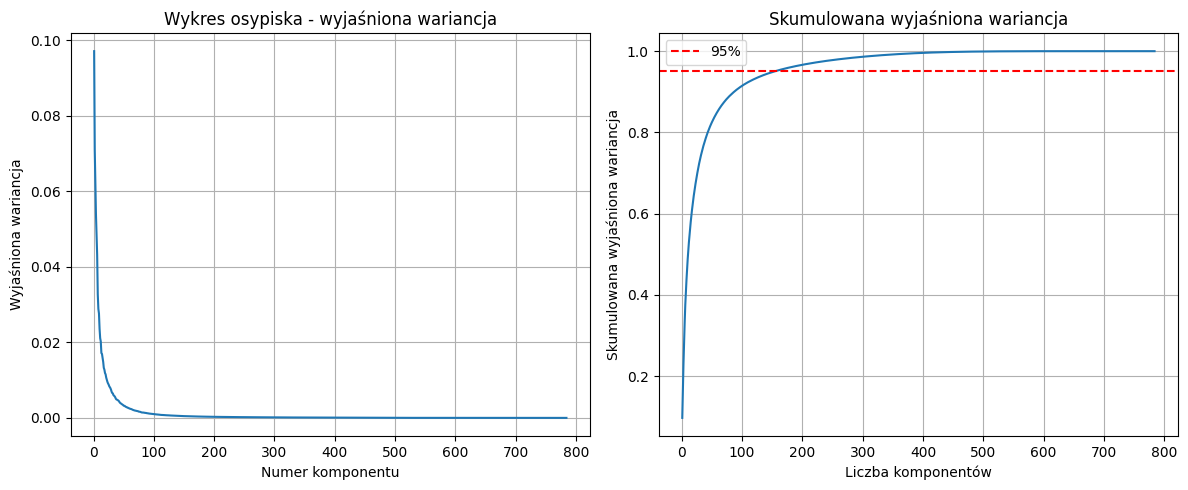

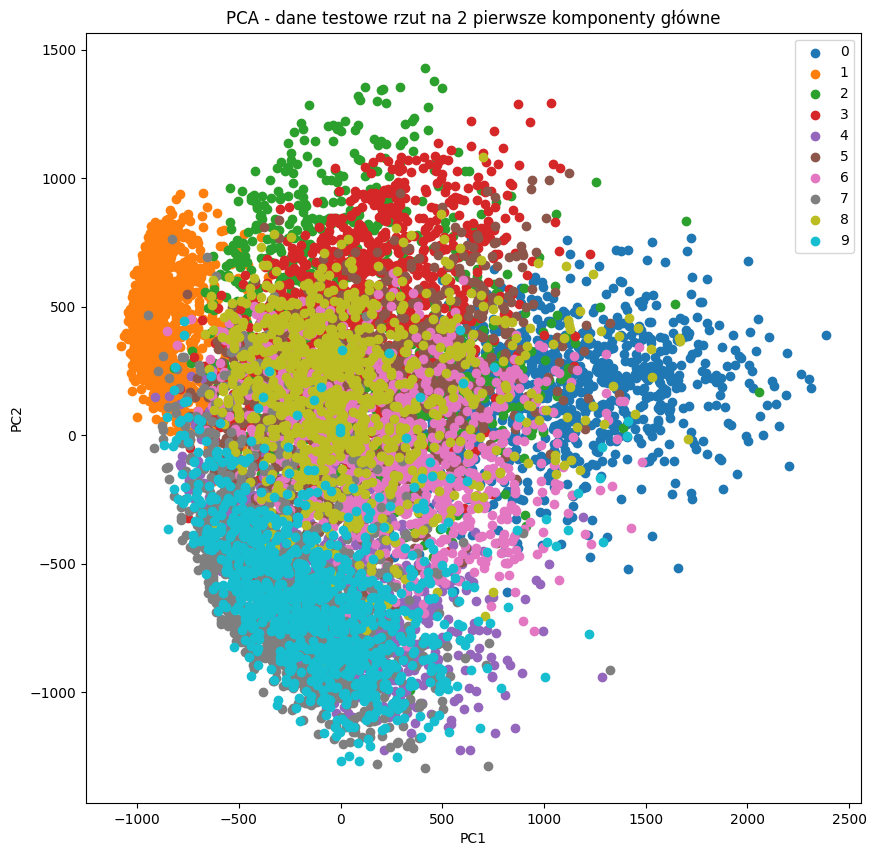

In [40]:
from sklearn.decomposition import PCA

# Spłaszcz dane treningowe do tablicy 2D (n_próbek, n_cech)
train_images_flat = train_data.data.numpy().reshape(len(train_data), -1)
test_images_flat = test_data.data.numpy().reshape(len(test_data), -1)
# Dopasuj PCA
pca = PCA()
pca.fit(train_images_flat)

# Wykres osypiska (wyjaśniona wariancja)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.xlabel('Numer komponentu')
plt.ylabel('Wyjaśniona wariancja')
plt.title('Wykres osypiska - wyjaśniona wariancja')
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Liczba komponentów')
plt.ylabel('Skumulowana wyjaśniona wariancja')
plt.title('Skumulowana wyjaśniona wariancja')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.legend()

plt.tight_layout()
plt.show()

# transformujemy dane testowe i pokazujemy je na wykresie 2D PCA

pca_2d = PCA(n_components=2)
pca_2d = pca_2d.fit(train_images_flat)
train_labels = train_data.targets.numpy()

test_transformed = pca_2d.transform(test_images_flat)
test_labels = test_data.targets.numpy()


plot_latent_space(test_transformed, test_labels,
                  title='PCA - dane testowe rzut na 2 pierwsze komponenty główne',
                  xlabel='PC1',
                  ylabel='PC2')

# UMAP
Jeśli przestrzeń jest więcej niż 2 wymiarowa warto ją jakoś zmapować na 2 wymiary w celu wizualizacji. Wykorzystamy do tego metodę UMAP.

UMAP (Uniform Manifold Approximation and Projection) to metoda redukcji wymiarowości, która przekształca dane z wysokowymiarowej przestrzeni (np. 10 wymiarów) do niskiej wymiarowości (np. 2D) zachowując przy tym zarówno lokalną jak i globalną strukturę danych.

Działa ona tworząc graf połączeń między najbliższymi punktami w oryginalnej przestrzeni, a następnie optymalizuje położenie punktów w przestrzeni docelowej tak, aby zachować te same relacje sąsiedztwa. W przeciwieństwie do starszych metod jak PCA (która zachowuje tylko odległości liniowe) czy t-SNE (która skupia się głównie na lokalnej strukturze), UMAP jest szybsza i lepiej zachowuje zarówno lokalne skupiska jak i globalne relacje między grupami danych.

Zobaczmy jak UMAP poradzi sobie z mapowaniem oryginalnych danych na 2 wymiary.

_Zwróćmy uwagę że w czasie fitowania transformacji nie używamy informacji o etykietach._

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


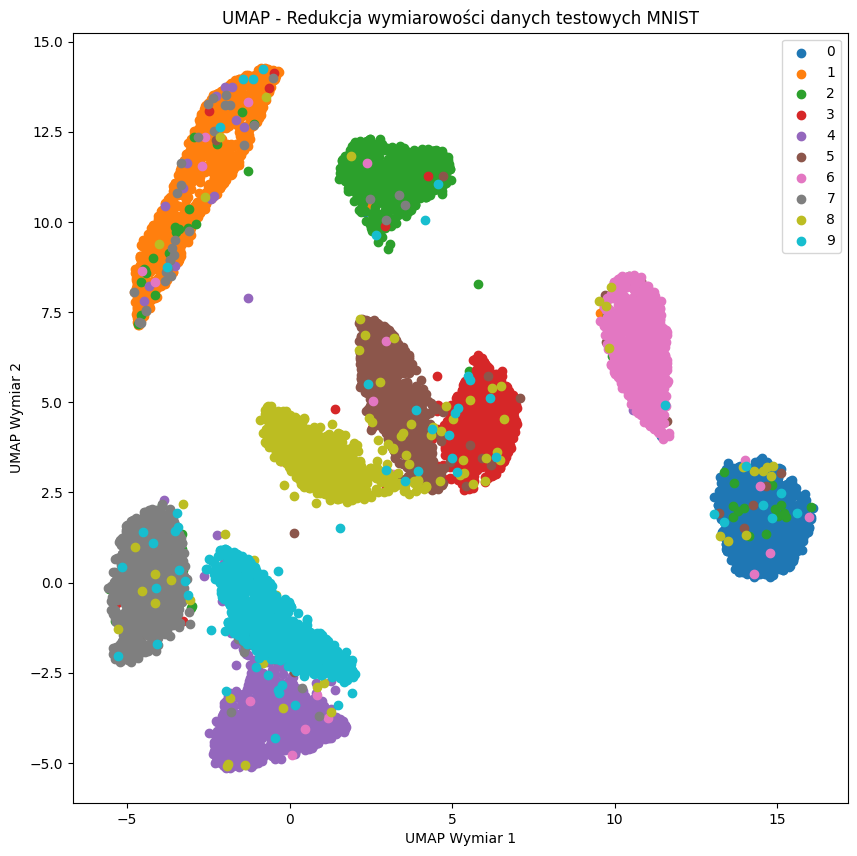

In [41]:
import umap
# Spłaszcz dane testowe do tablicy 2D (n_próbek, n_cech)
train_data_flat = train_data.data.numpy().reshape(len(train_data), -1)
test_images_flat = test_data.data.numpy().reshape(len(test_data), -1)
test_labels = test_data.targets.numpy()

# Dopasuj UMAP na danych treningowych
umap_model = umap.UMAP(n_components=2, random_state=seed)
train_umap_embedding = umap_model.fit_transform(train_data_flat)

# Transformuj dane testowe
test_umap_embedding = umap_model.transform(test_images_flat)
# Wizualizuj osadzenie UMAP
plot_latent_space(test_umap_embedding, test_labels,
                  title='UMAP - Redukcja wymiarowości danych testowych MNIST',
                  xlabel='UMAP Wymiar 1',
                  ylabel='UMAP Wymiar 2')

# Najprostszy autoencoder

## Budowa autoencodera

Autoencoder to sieć neuronowa składająca się z trzech głównych części:

1. **Encoder (enkoder)** - kompresuje dane wejściowe
   - Składa się z kilku warstw w pełni połączonych (fully connected)
   - Każda kolejna warstwa ma coraz mniej neuronów
   - Przykład: 784 → 400 → 10

2. **Bottleneck (przewężenie)** - najmniejsza warstwa pośrodku
   - To jest "serce" autoencodera
   - Ma znacznie mniej neuronów niż dane wejściowe
   - Tutaj przechowywana jest skompresowana reprezentacja danych (**_przestrzeń latentna_**)

3. **Decoder (dekoder)** - rekonstruuje dane z reprezentacji skompresowanej
   - Składa się z warstw zwiększających liczbę neuronów
   - Jest "lustrzanym odbiciem" enkodera
   - Przykład: 10 → 400 → 784

## Jak to działa?

**Cel**: Model uczy się odtworzyć na wyjściu dokładnie to, co dostał na wejściu.

**Kluczowa idea**: Ponieważ w przewężeniu jest znacznie mniej neuronów niż na wejściu (np. 10 vs 784), model **musi** nauczyć się kompresji danych. Nie może po prostu "przepisać" wszystkich wartości - musi wyodrębnić tylko **najważniejsze cechy**, które pozwolą później zrekonstruować oryginał.

## Po co nam to?

- **Redukcja wymiarowości**: zamiast 784 liczb mamy tylko 10, które zawierają esencję informacji
- **Wizualizacja**: przestrzeń 10-wymiarową można dalej zredukować (np. UMAP) i zobaczyć strukturę danych
- **Detekcja anomalii**: jeśli dane nie dają się dobrze zrekonstruować, mogą być nietypowe
- **Kompresja**: możemy efektywnie przechowywać dane w postaci skompresowanej

In [42]:
class AEBaseline(nn.Module):
  # https://github.com/snakers4/playing_with_vae/blob/master/VAE.py
    def __init__(self,
                 latent_space_size=2):
        super(AEBaseline, self).__init__()
        self.fc1 = nn.Linear(784, 400)
        self.fc2 = nn.Linear(400, latent_space_size)
        self.fc_2 = nn.Linear(latent_space_size, 400) # odwrotna operacja do fc2
        self.fc_1 = nn.Linear(400, 784) # odwrotna operacja do fc1

        print('Total model parameters {}'.format(self.count_parameters()))

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        h2 = self.fc2(h1)
        return h2

    def decode(self, z):
        h3 = F.relu(self.fc_2(z))
        h4 = self.fc_1(h3)
        return torch.sigmoid(h4)

    def forward(self, x):
        x = self.encode(x.view(-1, 784))
        z = x
        return self.decode(z), x, None

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

Total model parameters 630386
Model przyjmyje batch o takim kształcie:  torch.Size([512, 1, 28, 28])
A zwraca tensor o takim kształcie:  torch.Size([512, 784])
Model z losowymi wagami powinien na wyjściu zwrócić coś zbliżonego do szumu


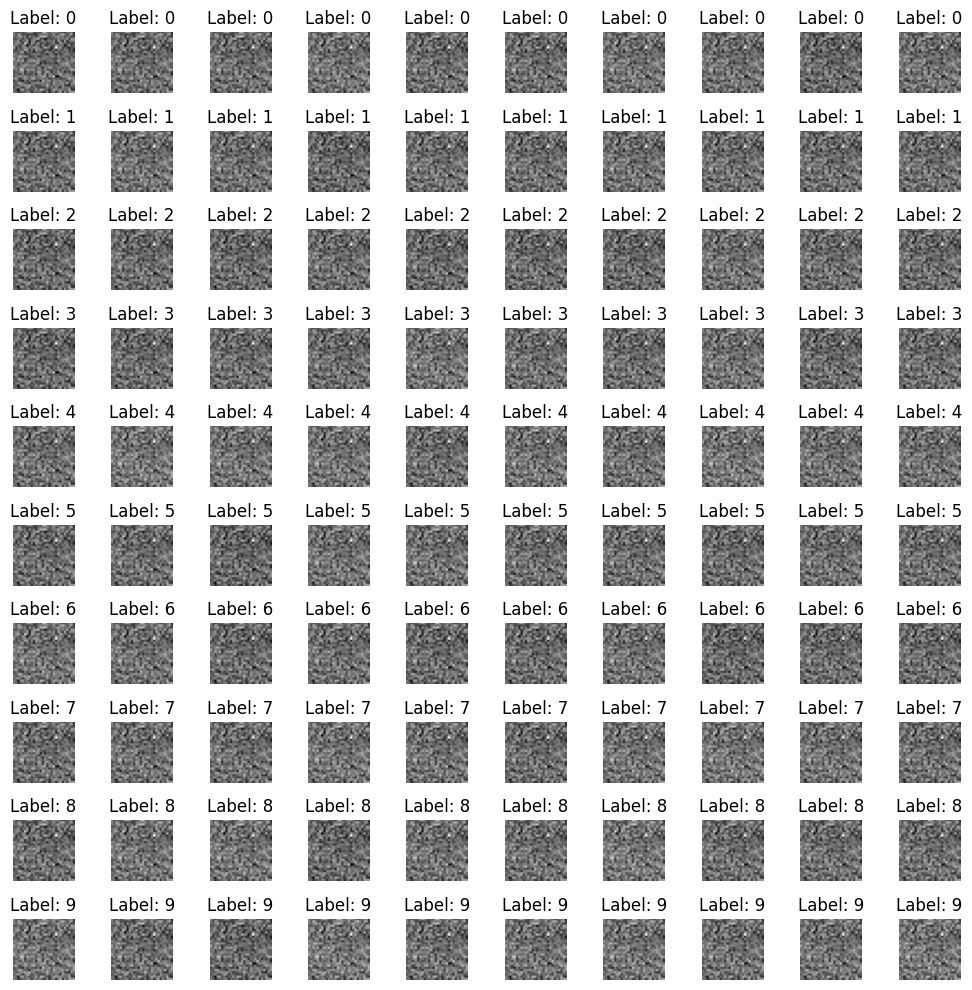

In [43]:
model_AE = AEBaseline()
model_AE.to(device=device, dtype=dtype)
train_features_batch, train_labels_batch = next(iter(train_dataloader))

train_features_batch = train_features_batch.to(device=device, dtype=dtype)

print('Model przyjmyje batch o takim kształcie: ', train_features_batch.shape)
out, z , _ = model_AE(train_features_batch)
print('A zwraca tensor o takim kształcie: ', out.shape)

print('Model z losowymi wagami powinien na wyjściu zwrócić coś zbliżonego do szumu')
pokaz_rekonstrukcje(model_AE, train_data, digit_indices, rng, device, rows=10, cols=10)

## Trenujemy model autoenkodera

In [44]:
learning_rate = 1e-3
lambda_l2 = 1e-5
epochs = 5
optimizer = torch.optim.Adam(model_AE.parameters(), lr=learning_rate, weight_decay=lambda_l2)

for epoch in range(1, epochs):
    train_loss = 0
    model_AE.train()
    for batch_idx, (data, _) in enumerate(train_dataloader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, _ = model_AE(data)
        loss = F.binary_cross_entropy(recon_batch.view(-1, 784), data.view(-1, 784), reduction='sum')
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    # Ewaluacja
    model_AE.eval()
    test_loss = 0
    with torch.no_grad():
        for i, (data, _) in enumerate(test_dataloader):
            data = data.to(device)
            recon_batch, mu, _ = model_AE(data)
            loss = F.binary_cross_entropy(recon_batch.view(-1, 784), data.view(-1, 784), reduction='sum')
            test_loss += loss.item()
    test_loss /= len(test_dataloader.dataset)
    print(f'====> Epoka: {epoch} Strata treningowa: {train_loss / len(train_dataloader.dataset):.4f} | Strata testowa: {test_loss:.4f}')

====> Epoka: 1 Strata treningowa: 210.8089 | Strata testowa: 178.3572
====> Epoka: 2 Strata treningowa: 173.3803 | Strata testowa: 168.9705
====> Epoka: 3 Strata treningowa: 166.3630 | Strata testowa: 164.1910
====> Epoka: 4 Strata treningowa: 162.6638 | Strata testowa: 161.2110


Po treningu rekonstrukcja wygląda tak:

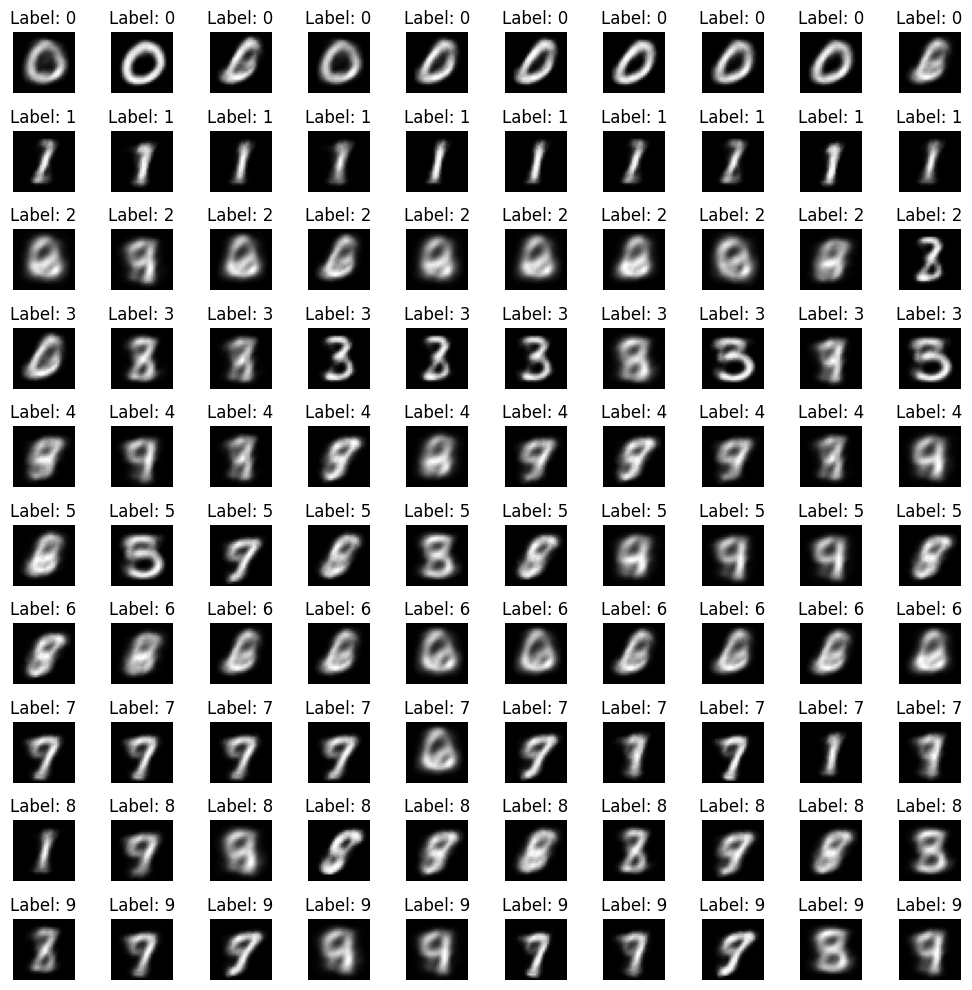

In [45]:
pokaz_rekonstrukcje(model_AE, train_data, digit_indices, rng, device, rows=10, cols=10)

## Zobaczmy latentne reprezentacje

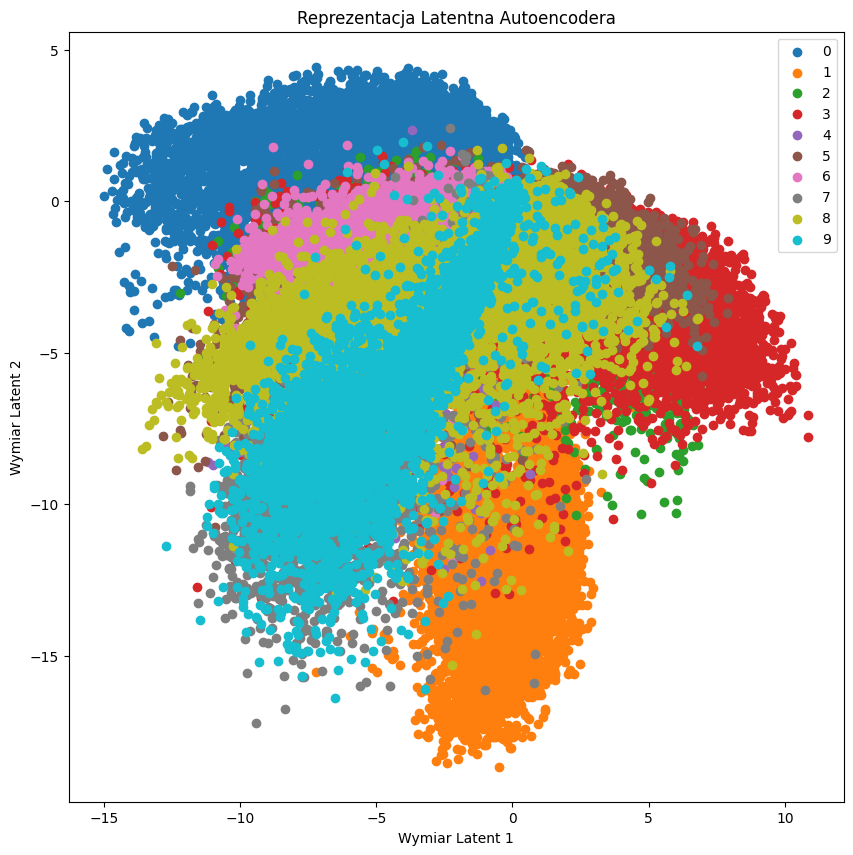

In [46]:
z_list, labels = extract_latent_representations(model_AE, train_dataloader, device)
plot_latent_space(z_list, labels, title='Reprezentacja Latentna Autoencodera', xlabel='Wymiar Latent 1', ylabel='Wymiar Latent 2')

# Autoencoder wariacyjny (Variational Autoencoder - VAE)

## Czym różni się od zwykłego autoencodera?

Zwykły autoencoder po prostu kompresuje dane do przestrzeni latentnej. VAE idzie krok dalej - **modeluje przestrzeń latentną jako rozkład prawdopodobieństwa**.

### Kluczowe różnice:

**Zwykły autoencoder:**
- Encoder zwraca konkretny punkt w przestrzeni latentnej: $z$
- Każdy obrazek mapowany jest na dokładnie jeden punkt

**VAE:**
- Encoder zwraca **parametry rozkładu**: średnią ($\mu$) i wariancję ($\sigma^2$)
- Każdy obrazek reprezentowany jest jako **rozkład normalny** wokół $\mu$ z rozrzutem $\sigma$
- Podczas treningu losujemy punkt z tego rozkładu: $z \sim {N}(\mu, \sigma^2)$

### Po co ta komplikacja?

1. **Gładka przestrzeń latentna**: Punkty leżące blisko siebie w przestrzeni latentnej reprezentują podobne obrazy. To pozwala na:
   - Interpolację między obrazami
   - Generowanie nowych, sensownych przykładów

2. **Regularyzacja**: Funkcja straty VAE składa się z dwóch części:
   - **Reconstruction loss (BCE)**: Jak dobrze odtwarzamy oryginał (tak jak w zwykłym AE)
   - **KL divergence (KLD)**: "Zmusza" rozkłady do przypominania standardowego rozkładu normalnego ${N}(0,1)$
   
   $$\text{Loss} = \text{BCE} + \beta \cdot \text{KLD}$$

3. **Generowanie nowych danych**: Po wytrenowaniu możemy:
   - Wylosować punkt z rozkładu ${N}(0,1)$
   - Przepuścić przez decoder
   - Otrzymać nowy, nigdy niewidziany obrazek cyfry.

### Reparametryzacja (reparameterization trick)

Problem: Nie można backpropagować przez operację losowania.

Rozwiązanie: Zamiast losować $z$ bezpośrednio, używamy:
$$z = \mu + \sigma \cdot \epsilon$$
gdzie $\epsilon \sim {N}(0,1)$ jest losowane niezależnie.

Teraz gradient może "przepłynąć" przez $\mu$ i $\sigma$.

## Funkcja straty VAE - matematyczne uzasadnienie

### Reconstruction Loss
Pierwsza część straty to Binary Cross-Entropy (BCE), która mierzy jak dobrze rekonstruujemy obraz:
$$\text{BCE} = -\sum_{i=1}^{784} [x_i \log(\hat{x}_i) + (1-x_i)\log(1-\hat{x}_i)]$$

### KL Divergence - matematyczne wyprowadzenie

**Definicja ogólna KL divergence:**

KL divergence mierzy "odległość" między dwoma rozkładami prawdopodobieństwa $P$ i $Q$:
$$D_{KL}(P \parallel Q) = \int P(x) \log \frac{P(x)}{Q(x)} dx$$

Interpretacja: "Jak bardzo rozkład $P$ różni się od rozkładu $Q$". Zawsze $D_{KL} \geq 0$, równość zachodzi tylko gdy $P = Q$.

**W kontekście VAE:**

Dla każdego obrazka encoder produkuje rozkład $q(z|x) = {N}(\mu, \sigma^2)$, który chcemy porównać ze standardowym rozkładem normalnym $p(z) = {N}(0, 1)$.

KL divergence między dwoma rozkładami normalnymi ma analityczną formę:
$$D_{KL}(q(z|x) \parallel p(z)) = D_{KL}({N}(\mu, \sigma^2) \parallel {N}(0, 1))$$

Po przeprowadzeniu całkowania otrzymujemy:
$$D_{KL} = \frac{1}{2} \sum_{j=1}^{J} (\mu_j^2 + \sigma_j^2 - \log(\sigma_j^2) - 1)$$

gdzie $J$ to wymiarowość przestrzeni latentnej.

**Intuicja matematyczna poszczególnych składników:**

- $\mu_j^2$: karze za oddalanie się średniej od zera (centrum)
- $\sigma_j^2$: karze za zbyt duży rozrzut (wariancję większą niż 1)
- $-\log(\sigma_j^2)$: karze za zbyt mały rozrzut (zapobiega kolapsowi wariancji do zera)
- $-1$: stała normalizująca (gdy $\mu=0$ i $\sigma^2=1$, wszystkie składniki się zerują)

**W kodzie PyTorch:**

Używamy parametryzacji przez `logvar` = $\log(\sigma^2)$ dla stabilności numerycznej:
$$D_{KL} = -\frac{1}{2} \sum_{j=1}^{J} (1 + \text{logvar}_j - \mu_j^2 - \exp(\text{logvar}_j))$$


In [47]:
def vae_loss_function(recon_x, x, mu, logvar, kl_weight=1.0):
    """
    Suma strat rekonstrukcji + KL divergence dla wszystkich elementów i batcha.

    Zobacz Dodatek B z artykułu VAE:
    Kingma and Welling. Auto-Encoding Variational Bayes. ICLR, 2014
    https://arxiv.org/abs/1312.6114
    0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)

    Args:
        kl_weight: Waga dla składnika KL divergence (dla KL annealing)
    """
    BCE = F.binary_cross_entropy(recon_x.view(-1, 784), x.view(-1, 784), size_average=False)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + kl_weight * KLD, BCE, KLD

Klasa prostego autoencodera wariacyjnego zaczerpnięta z https://github.com/snakers4/playing_with_vae/blob/master/VAE.py :

In [48]:
class VAEBaseline(nn.Module):
    def __init__(self,
                 latent_space_size=2):
        super(VAEBaseline, self).__init__()
        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, latent_space_size) # warstwa dla mu
        self.fc22 = nn.Linear(400, latent_space_size) # warstwa dla logvar
        self.fc3 = nn.Linear(latent_space_size, 400)
        self.fc4 = nn.Linear(400, 784)

        print('Total model parameters {}'.format(self.count_parameters()))

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mu = self.fc21(h1)
        logvar = self.fc22(h1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5*logvar)
            eps = torch.randn_like(std)
            return eps.mul(std).add_(mu)
        else:
            return mu

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return F.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

Testy wymiarów i przepuszczania danych przez model

Total model parameters 631188
Model przyjmyje batch o takim kształcie:  torch.Size([512, 1, 28, 28])
A zwraca tensor o takim kształcie:  torch.Size([512, 784])
Tak wygląda rekonstrukcja przed treningiem:


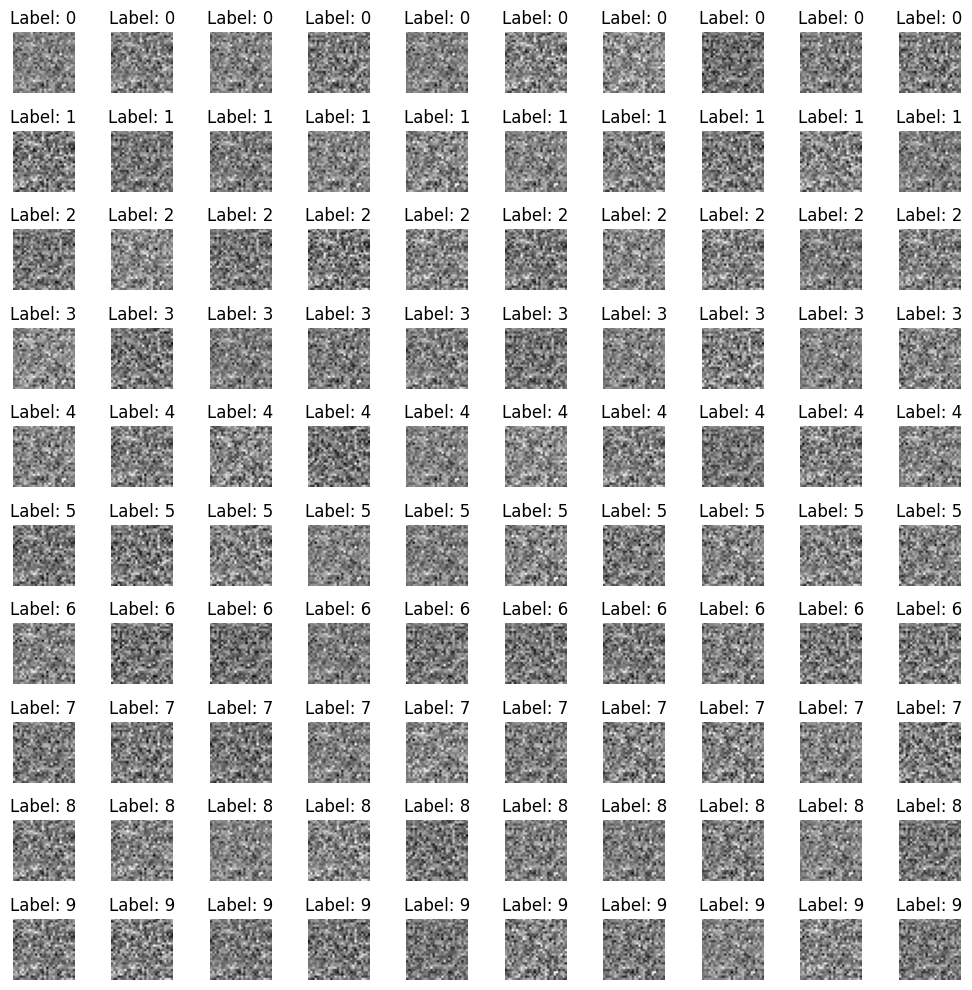

In [49]:
model_VAE = VAEBaseline()
model_VAE.to(device=device, dtype=dtype)
train_features_batch, train_labels_batch = next(iter(train_dataloader))

train_features_batch = train_features_batch.to(device=device, dtype=dtype)

print('Model przyjmyje batch o takim kształcie: ', train_features_batch.shape)
out, mu, logvar = model_VAE(train_features_batch)
print('A zwraca tensor o takim kształcie: ', out.shape)

# Tak wygląda rekonstrukcja przed treningiem
print('Tak wygląda rekonstrukcja przed treningiem:')
pokaz_rekonstrukcje(model_VAE, train_data, digit_indices, rng, device, rows=10, cols=10)

Trening VAE:

====> Epoka: 1 Strata treningowa: 226.0412 | Strata testowa: 185.3784
====> Epoka: 2 Strata treningowa: 181.7789 | Strata testowa: 176.0219
====> Epoka: 3 Strata treningowa: 174.5348 | Strata testowa: 170.5621
====> Epoka: 4 Strata treningowa: 169.9566 | Strata testowa: 167.1779
Tak wygląda rekonstrukcja po treningu:


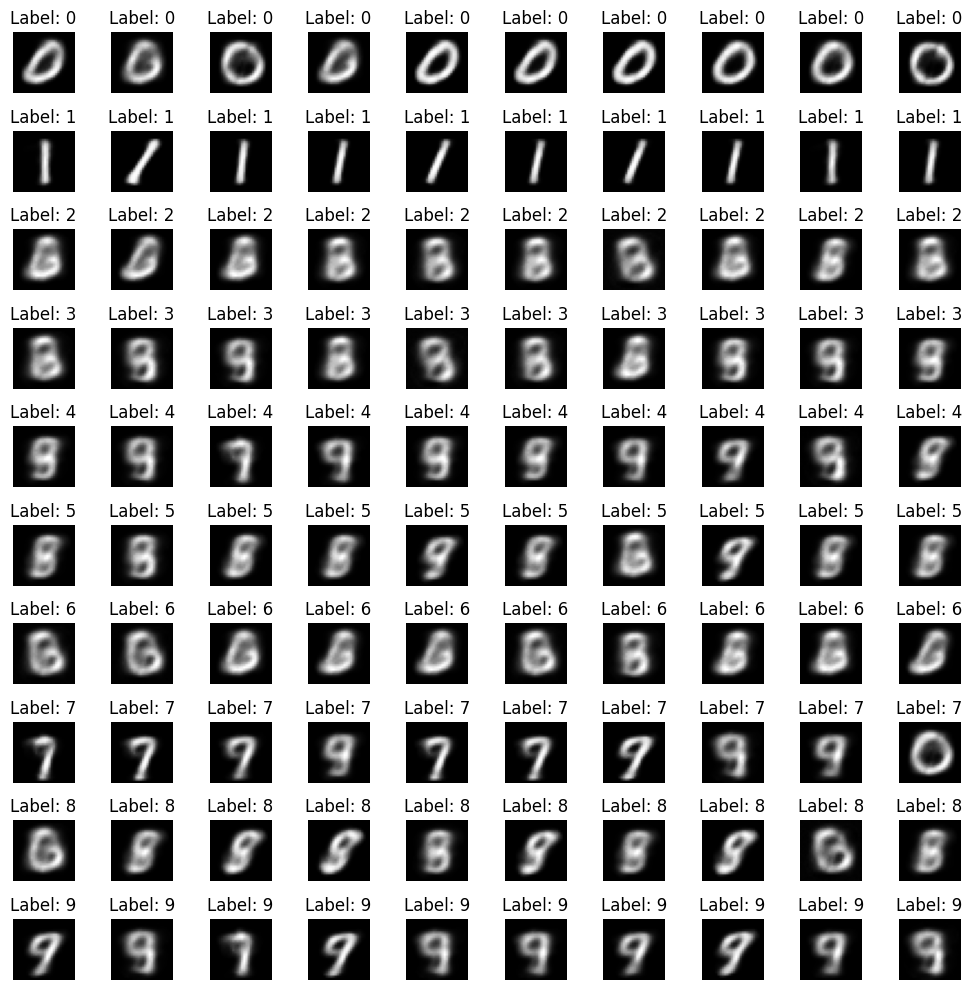

In [50]:
learning_rate = 1e-3
lambda_l2 = 1e-5
epochs = 5 #150
optimizer = torch.optim.Adam(model_VAE.parameters(), lr=learning_rate, weight_decay=lambda_l2)

for epoch in range(1, epochs):
    train_loss = 0
    model_VAE.train()
    for batch_idx, (data, _) in enumerate(train_dataloader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model_VAE(data)
        loss, BCE, KLD = vae_loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    # Ewaluacja
    model_VAE.eval()
    test_loss = 0

    with torch.no_grad():
        for i, (data, _) in enumerate(test_dataloader):
            data = data.to(device)
            recon_batch, mu, logvar = model_VAE(data)
            loss, BCE, KLD = vae_loss_function(recon_batch, data, mu, logvar)
            test_loss += loss

    test_loss /= len(test_dataloader.dataset)
    print(f'====> Epoka: {epoch} Strata treningowa: {train_loss / len(train_dataloader.dataset):.4f} | Strata testowa: {test_loss:.4f}')

print('Tak wygląda rekonstrukcja po treningu:')
pokaz_rekonstrukcje(model_VAE, train_data, digit_indices, rng, device, rows=10, cols=10)

# Zobaczmy jak układają się cyfry ze zbioru testowego w przestrzeni latentnej

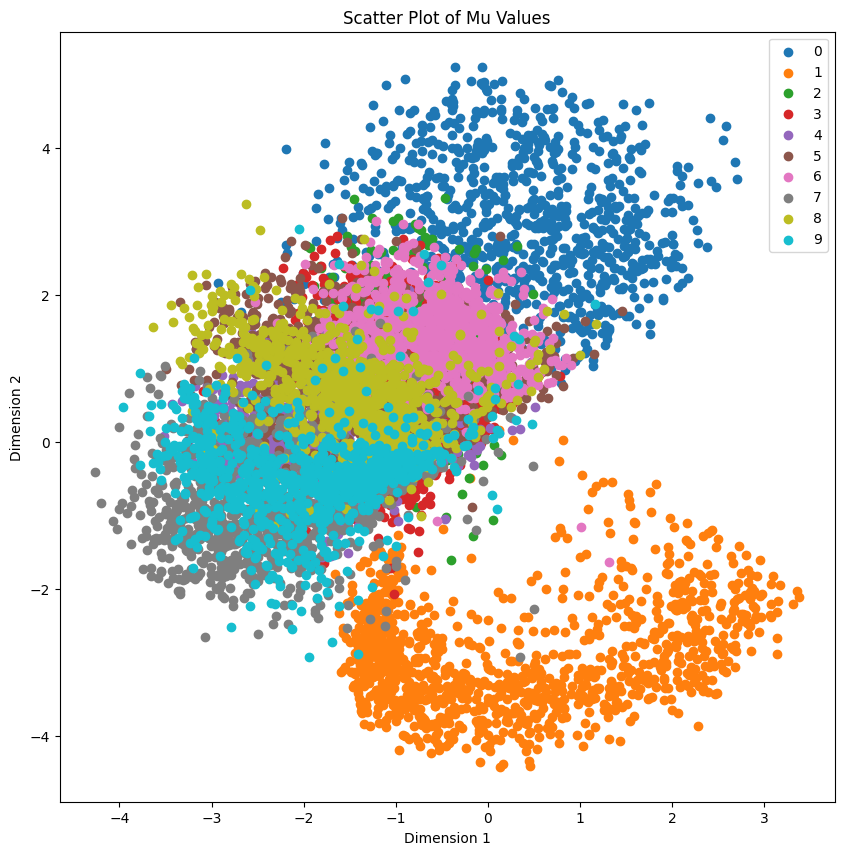

In [51]:
mu_list, labels = extract_latent_representations(model_VAE, test_dataloader, device)
plot_latent_space(mu_list, labels)

# Sprawdźmy co się stanie jeśli zwiększymy wymiarowość przestrzeni latentnej?

Total model parameters 640804
====> Epoka: 1 Strata treningowa: 219.9560 | Strata testowa: 163.7159
====> Epoka: 2 Strata treningowa: 149.8529 | Strata testowa: 138.9606
====> Epoka: 3 Strata treningowa: 134.4527 | Strata testowa: 129.7644
====> Epoka: 4 Strata treningowa: 128.2755 | Strata testowa: 125.3342
Tak wygląda rekonstrukcja po treningu:


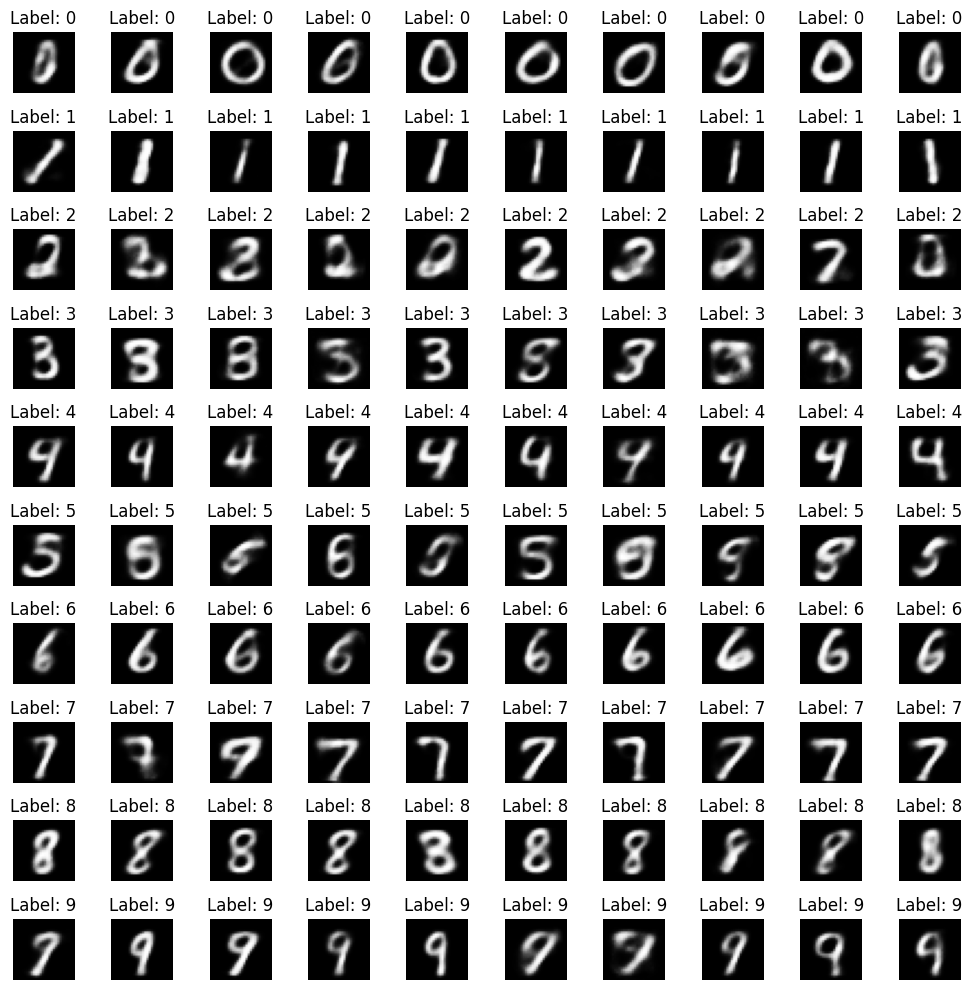

In [52]:
learning_rate = 1e-3
lambda_l2 = 1e-5
epochs = 5
model_VAE2 = VAEBaseline(latent_space_size=10) # zwiększamy wymiar przestrzeni latentnej do 10
model_VAE2.to(device=device, dtype=dtype)

optimizer = torch.optim.Adam(model_VAE2.parameters(), lr=learning_rate, weight_decay=lambda_l2)

for epoch in range(1, epochs):
    train_loss = 0
    model_VAE2.train()
    for batch_idx, (data, _) in enumerate(train_dataloader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model_VAE2(data)
        loss, BCE, KLD = vae_loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    # Ewaluacja
    model_VAE.eval()
    test_loss = 0

    with torch.no_grad():
        for i, (data, _) in enumerate(test_dataloader):
            data = data.to(device)
            recon_batch, mu, logvar = model_VAE2(data)
            loss, BCE, KLD = vae_loss_function(recon_batch, data, mu, logvar)
            test_loss += loss

    test_loss /= len(test_dataloader.dataset)
    print(f'====> Epoka: {epoch} Strata treningowa: {train_loss / len(train_dataloader.dataset):.4f} | Strata testowa: {test_loss:.4f}')

print('Tak wygląda rekonstrukcja po treningu:')
pokaz_rekonstrukcje(model_VAE2, train_data, digit_indices, rng, device, rows=10, cols=10)

Teraz przestrzeń latentna ma więcej wymiarów więc trzeba ją dla wizualizacji zmapować np.  UMAP do 2D:

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


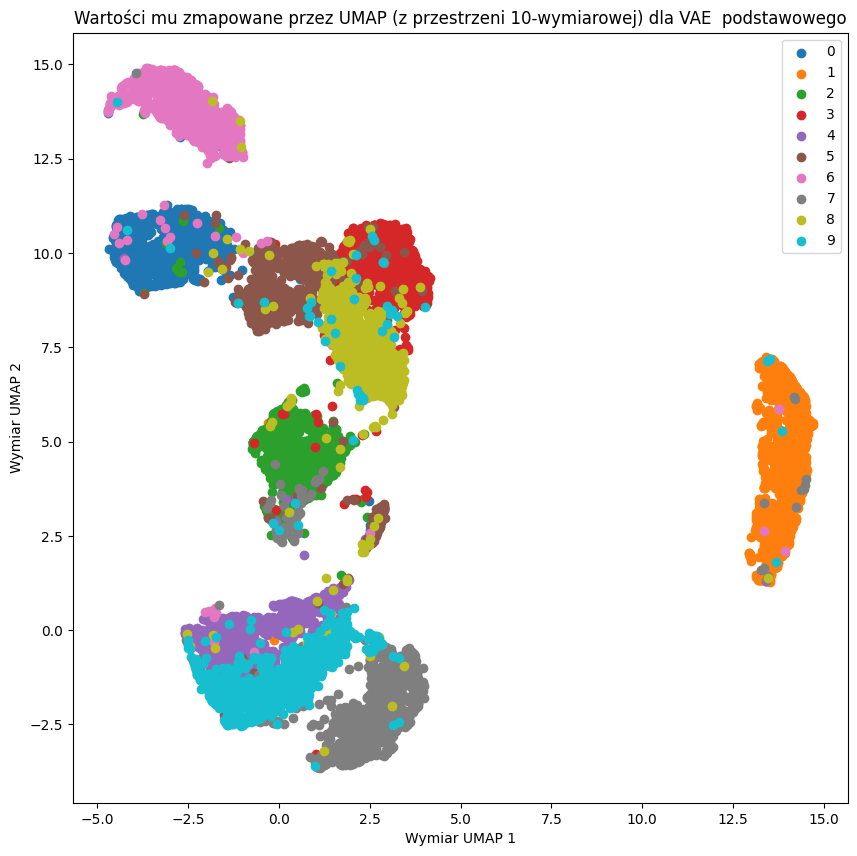

In [58]:
mu_list, labels = extract_latent_representations(model_VAE2, test_dataloader, device)

mu = mu_list.numpy()
# Dla wizualizacji przestrzeń w której są wektory mu zmapujemy do 2 wymiarowej reprezentacji za pomocą UMAP
if mu.shape[1] > 2:
    map = umap.UMAP()
    embedding = map.fit_transform(mu)
else:
    embedding = mu

plot_latent_space(embedding, labels,
                  title='Wartości mu zmapowane przez UMAP (z przestrzeni 10-wymiarowej) dla VAE  podstawowego',
                  xlabel='Wymiar UMAP 1',
                  ylabel='Wymiar UMAP 2')

# Wersja z architekturą konwolucyjną

W budowie autoenkodera dla obrazków można też wykorzystać warstwy konwolucyjne. Warto zauważyć że jeśli w enkoderze wykorzysujemy warstwy `Conv2d` to w dekoderze potrzebować będziemy ich odwrotności `ConvTranspose2d`.

### Jak działa ConvTranspose2d?

**Konwolucja transpozycyjna** (czasem nazywana "dekonwolucją", choć to nieścisłe) to operacja **odwrotna do zwykłej konwolucji** - zamiast zmniejszać wymiary obrazu, je **powiększa**.

**Intuicja:**
- `Conv2d`: Wiele pikseli wejściowych → jeden piksel wyjściowy (kompresja)
- `ConvTranspose2d`: Jeden piksel wejściowy → wiele pikseli wyjściowych (ekspansja)

**Jak to działa mechanicznie?**
Każda wartość w mniejszym tensorze jest "rozmazywana" przez filtr (kernel) na większy obszar w tensorze wyjściowym. Nakładające się regiony są sumowane. Dzięki temu np. wymiar 14x14 → 28x28 (gdy `stride=2`)


**Parametry kluczowe:**
- `stride`: O ile "rozciągamy" obraz (stride=2 podwaja wymiary)
- `padding`: Ile obcinamy z brzegów
- `output_padding`: Dodatkowe piksele na końcu, gdy stride daje niejednoznaczność rozmiaru

**W VAE:** `ConvTranspose2d` w dekoderze rekonstruuje pełnowymiarowy obraz (28x28) z małej reprezentacji (14x14), będąc lustrzanym odbiciem `Conv2d` z enkodera.

In [55]:
class VAE_conv(nn.Module):
    def __init__(self,
                 latent_space_size=2):
        super(VAE_conv, self).__init__()
        # Enkoder: 28x28x1 -> 28x28x32 -> 28x28x64 -> 14x14x16
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 16, kernel_size=3, stride=2, padding=1)

        self.fc21 = nn.Linear(16*14*14, latent_space_size)
        self.fc22 = nn.Linear(16*14*14, latent_space_size)

        # Dekoder: latent -> 16x14x14 -> 64x28x28 -> 32x28x28 -> 1x28x28
        self.fc3 = nn.Linear(latent_space_size, 16*14*14)
        self.deconv1 = nn.ConvTranspose2d(16, 64, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.deconv2 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=1, padding=1)
        self.deconv3 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1)
        print('Total model parameters {}'.format(self.count_parameters()))

    def encode(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(-1, 16*14*14)
        mu = self.fc21(x)
        logvar = self.fc22(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5*logvar)
            eps = torch.randn_like(std)
            return eps.mul(std).add_(mu)
        else:
            return mu

    def decode(self, z):
        z = F.relu(self.fc3(z))
        z = z.view(-1, 16, 14, 14)
        z = F.relu(self.deconv1(z))
        z = F.relu(self.deconv2(z))
        z = self.deconv3(z)  # Bez ReLU przed sigmoid!
        return torch.sigmoid(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

### Sprawdźmy czy ten model daje lepszą separację cyfr w przestrzeni latentnej (Samodzielnie)

Proszę zwrócić uwagę na liczbę parametrów

Total model parameters 153317
====> Epoka: 1 Strata treningowa: 259.7967 | Strata testowa: 125.3411
====> Epoka: 2 Strata treningowa: 172.0285 | Strata testowa: 125.2786
====> Epoka: 3 Strata treningowa: 135.1613 | Strata testowa: 125.3009
====> Epoka: 4 Strata treningowa: 125.5241 | Strata testowa: 125.3503
Tak wygląda rekonstrukcja po treningu:


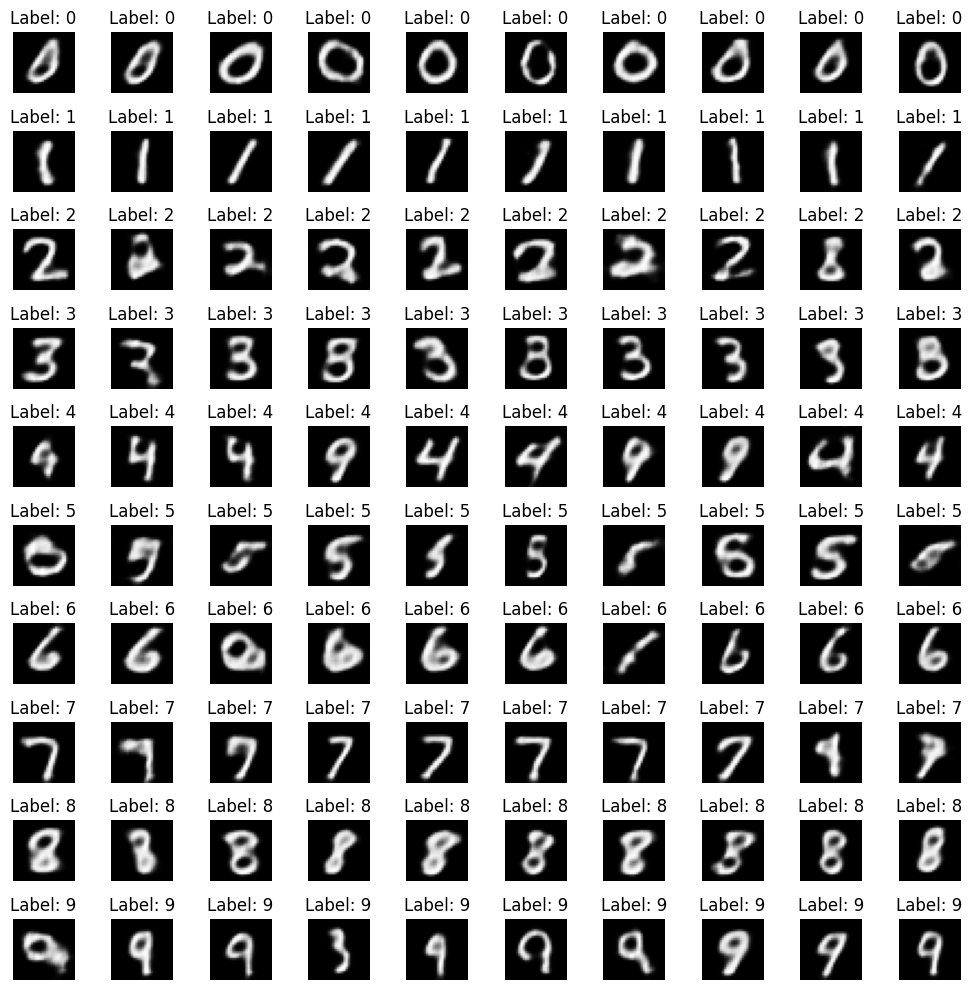

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


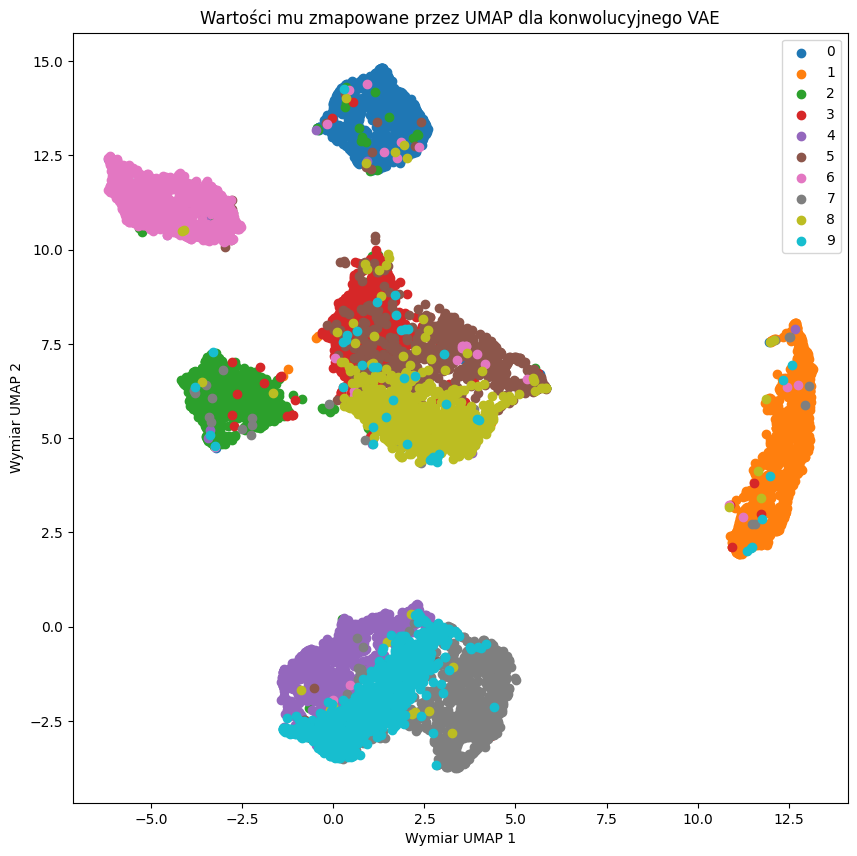

In [57]:
learning_rate = 1e-3
lambda_l2 = 1e-5
epochs = 5
model_VAE3 = VAE_conv(latent_space_size=10) # zwiększamy wymiar przestrzeni latentnej do 10
model_VAE3.to(device=device, dtype=dtype)

optimizer = torch.optim.Adam(model_VAE3.parameters(), lr=learning_rate, weight_decay=lambda_l2)

for epoch in range(1, epochs):
    train_loss = 0
    model_VAE3.train()
    for batch_idx, (data, _) in enumerate(train_dataloader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model_VAE3(data)
        loss, BCE, KLD = vae_loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    # Ewaluacja
    model_VAE.eval()
    test_loss = 0

    with torch.no_grad():
        for i, (data, _) in enumerate(test_dataloader):
            data = data.to(device)
            recon_batch, mu, logvar = model_VAE2(data)
            loss, BCE, KLD = vae_loss_function(recon_batch, data, mu, logvar)
            test_loss += loss

    test_loss /= len(test_dataloader.dataset)
    print(f'====> Epoka: {epoch} Strata treningowa: {train_loss / len(train_dataloader.dataset):.4f} | Strata testowa: {test_loss:.4f}')

print('Tak wygląda rekonstrukcja po treningu:')
pokaz_rekonstrukcje(model_VAE3, train_data, digit_indices, rng, device, rows=10, cols=10)

mu_list, labels = extract_latent_representations(model_VAE3, test_dataloader, device)

mu = mu_list.numpy()
# Dla wizualizacji przestrzeń w której są wektory mu zmapujemy do 2 wymiarowej reprezentacji za pomocą UMAP
if mu.shape[1] > 2:
    map = umap.UMAP()
    embedding = map.fit_transform(mu)
else:
    embedding = mu

plot_latent_space(embedding, labels,
                  title='Wartości mu zmapowane przez UMAP dla konwolucyjnego VAE',
                  xlabel='Wymiar UMAP 1',
                  ylabel='Wymiar UMAP 2')

## Co to jest KL Annealing?

**Problem:** Na początku treningu VAE często "ignoruje" przestrzeń latentną i próbuje tylko rekonstruować obrazy (minimalizować BCE). KL divergence wymusza regularyzację, co początkowo pogarsza rekonstrukcję.

**Rozwiązanie - KL Annealing:** Stopniowo zwiększamy wagę składnika KLD w funkcji straty:
$$\text{Loss} = \text{BCE} + \beta(t) \cdot \text{KLD}$$

gdzie $\beta(t)$ rośnie od 0 do 1 w ciągu pierwszych epok.

**Zalety:**
- Model najpierw uczy się dobrej rekonstrukcji
- Potem stopniowo wprowadzamy regularyzację przestrzeni latentnej
- Lepsze wyniki końcowe i stabilniejszy trening

W kodzie poniżej $\beta$ rośnie liniowo przez 10 pierwszych epok.

Total model parameters 153317
====> Epoka: 1 (Waga KL: 0.10) Strata treningowa: 248.4641 | Strata testowa: 171.0155
====> Epoka: 2 (Waga KL: 0.20) Strata treningowa: 140.2989 | Strata testowa: 119.2928
====> Epoka: 3 (Waga KL: 0.30) Strata treningowa: 116.6649 | Strata testowa: 110.0216
====> Epoka: 4 (Waga KL: 0.40) Strata treningowa: 112.2444 | Strata testowa: 107.5101
====> Epoka: 5 (Waga KL: 0.50) Strata treningowa: 110.8380 | Strata testowa: 105.9153
====> Epoka: 6 (Waga KL: 0.60) Strata treningowa: 110.4851 | Strata testowa: 106.0125
====> Epoka: 7 (Waga KL: 0.70) Strata treningowa: 110.8880 | Strata testowa: 106.6416
====> Epoka: 8 (Waga KL: 0.80) Strata treningowa: 111.7893 | Strata testowa: 106.7320
====> Epoka: 9 (Waga KL: 0.90) Strata treningowa: 112.7141 | Strata testowa: 107.2497
====> Epoka: 10 (Waga KL: 1.00) Strata treningowa: 113.7747 | Strata testowa: 107.7039
====> Epoka: 11 (Waga KL: 1.00) Strata treningowa: 113.0716 | Strata testowa: 107.1123
====> Epoka: 12 (Waga 

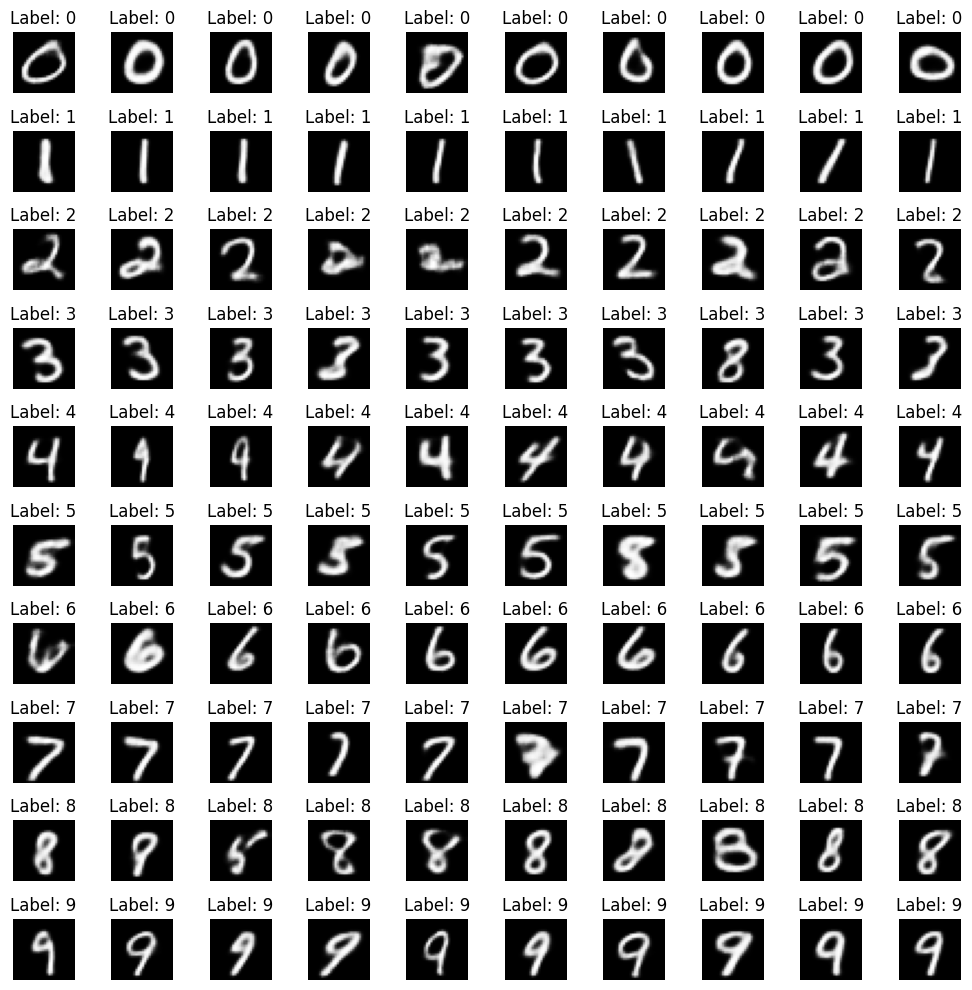

In [59]:
learning_rate = 1e-3
lambda_l2 = 1e-5
epochs = 20

model_VAE_conv = VAE_conv(latent_space_size=10)
model_VAE_conv.to(device=device, dtype=dtype)

optimizer = torch.optim.Adam(model_VAE_conv.parameters(), lr=learning_rate, weight_decay=lambda_l2)

# KL Annealing - stopniowe zwiększanie wagi KL divergence
kl_annealing_epochs = 10  # Przez ile epok zwiększać wagę KLD

for epoch in range(1, epochs + 1):
    train_loss = 0
    model_VAE_conv.train()

    # Waga KL - zaczyna od 0 i rośnie do 1
    kl_weight = min(1.0, epoch / kl_annealing_epochs)

    for batch_idx, (data, _) in enumerate(train_dataloader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model_VAE_conv(data)

        loss, BCE, KLD = vae_loss_function(recon_batch, data, mu, logvar, kl_weight)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    # Ewaluacja
    model_VAE_conv.eval()
    test_loss = 0

    with torch.no_grad():
        for i, (data, _) in enumerate(test_dataloader):
            data = data.to(device)
            recon_batch, mu, logvar = model_VAE_conv(data)
            loss, BCE, KLD = vae_loss_function(recon_batch, data, mu, logvar, kl_weight)
            test_loss += loss

    test_loss /= len(test_dataloader.dataset)
    print(f'====> Epoka: {epoch} (Waga KL: {kl_weight:.2f}) Strata treningowa: {train_loss / len(train_dataloader.dataset):.4f} | Strata testowa: {test_loss:.4f}')

print('\nTak wygląda rekonstrukcja po treningu:')
pokaz_rekonstrukcje(model_VAE_conv, train_data, digit_indices, rng, device, rows=10, cols=10)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


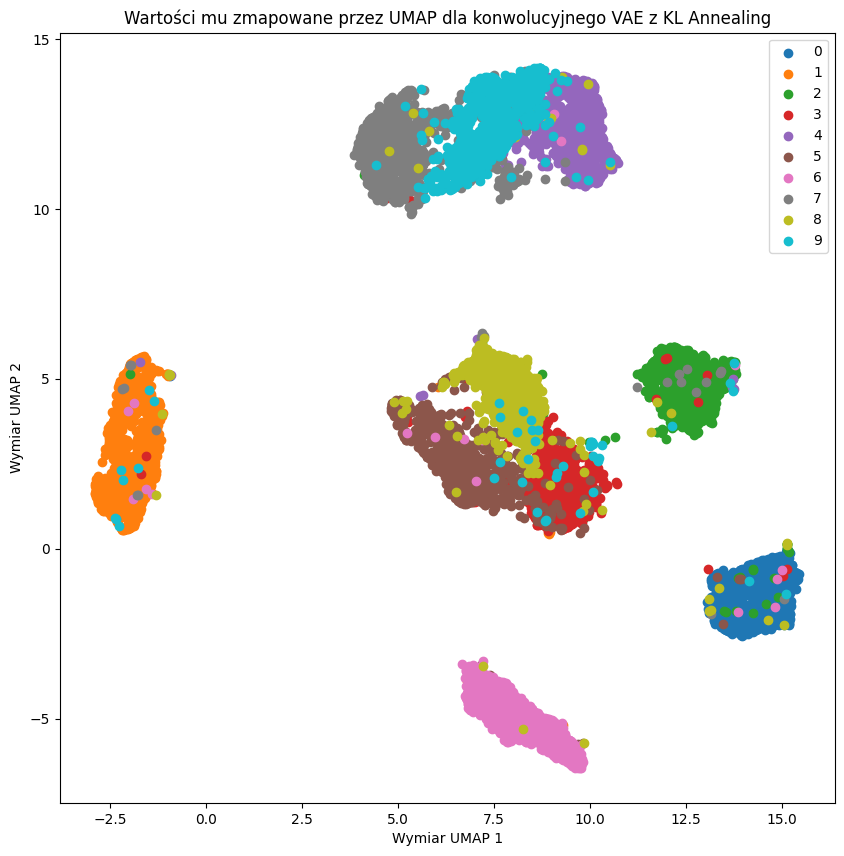

In [61]:
mu_list, labels = extract_latent_representations(model_VAE_conv, test_dataloader, device)

mu = mu_list.numpy()
# Dla wizualizacji przestrzeń w której są wektory mu zmapujemy do 2 wymiarowej reprezentacji za pomocą UMAP
import umap
if mu.shape[1] > 2: # Tylko jeżeli wymiar latentny jest większy niż 2
    map = umap.UMAP()
    embedding = map.fit_transform(mu)
else:
    embedding = mu

plot_latent_space(embedding, labels,
                  title='Wartości mu zmapowane przez UMAP dla konwolucyjnego VAE z KL Annealing',
                  xlabel='Wymiar UMAP 1',
                  ylabel='Wymiar UMAP 2')

# Interpolacja w przestrzeni latentnej

Kolejną właściwością VAE jest **gładka przestrzeń latentna**. Punkty leżące blisko siebie reprezentują podobne obrazy. Możemy więc "przejść" od jednej cyfry do drugiej poprzez interpolację w przestrzeni latentnej.

Zobaczmy jak wygląda transformacja jednej cyfry w drugą:

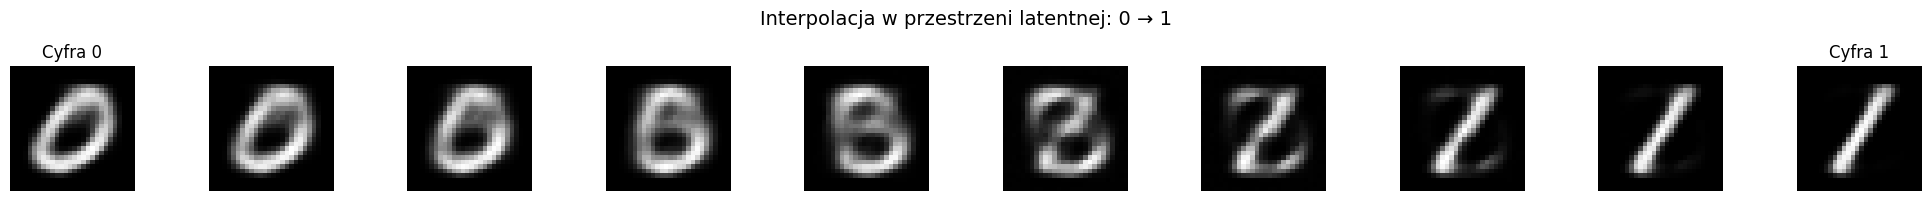

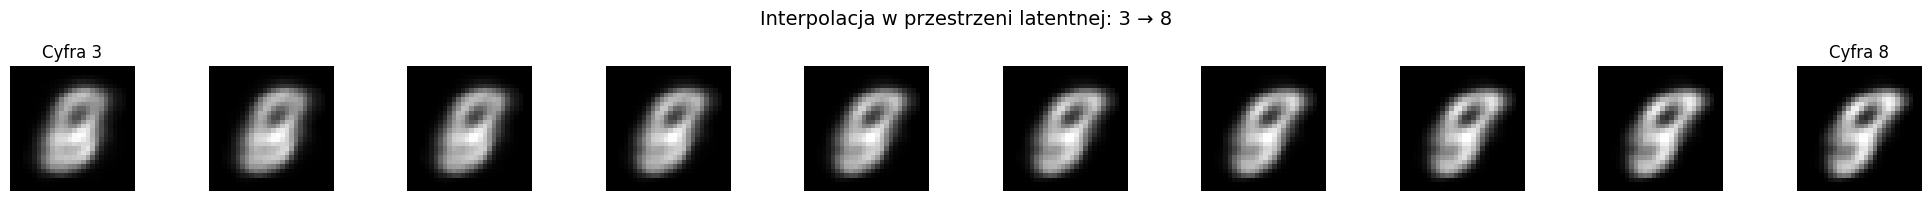

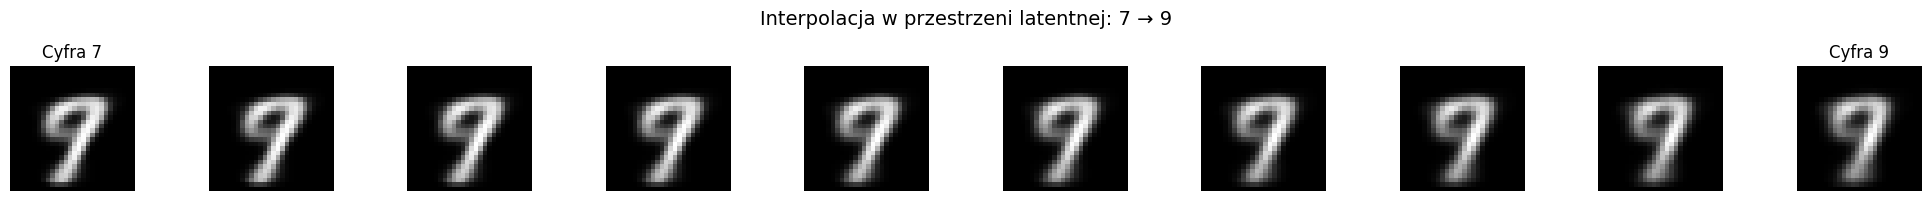

In [ ]:
def interpolate_between_images(model, data, device, idx1, idx2, n_steps=10):
    """
    Interpolacja między dwoma obrazami w przestrzeni latentnej.

    Args:
        model: Wytrenowany VAE
        data: Zbiór danych
        device: Urządzenie
        idx1, idx2: Indeksy dwóch obrazów
        n_steps: Liczba kroków interpolacji
    """
    model.eval()

    # Pobierz reprezentacje latentne dwóch obrazów
    img1, label1 = data[idx1]
    img2, label2 = data[idx2]

    with torch.no_grad():
        img1 = img1.unsqueeze(0).to(device)
        img2 = img2.unsqueeze(0).to(device)

        _, mu1, _ = model(img1)
        _, mu2, _ = model(img2)

        # Interpolacja w przestrzeni latentnej
        fig, axes = plt.subplots(1, n_steps, figsize=(20, 2))
        for i, alpha in enumerate(np.linspace(0, 1, n_steps)):
            z_interp = (1 - alpha) * mu1 + alpha * mu2
            img_interp = model.decode(z_interp)

            axes[i].imshow(img_interp.cpu().squeeze().reshape(28, 28), cmap='gray')
            axes[i].axis('off')
            if i == 0:
                axes[i].set_title(f'Cyfra {label1}')
            elif i == n_steps - 1:
                axes[i].set_title(f'Cyfra {label2}')

        plt.suptitle(f'Interpolacja w przestrzeni latentnej: {label1} → {label2}', fontsize=14)
        plt.tight_layout()
        plt.show()

# Przykład: interpolacja między różnymi cyframi
# Znajdźmy przykłady różnych cyfr
examples = {}
for i in range(len(train_data)):
    _, label = train_data[i]
    if label not in examples:
        examples[label] = i
    if len(examples) == 10:
        break

# Interpolacja między kilkoma parami
interpolate_between_images(model_VAE, train_data, device, examples[0], examples[1], n_steps=10)
interpolate_between_images(model_VAE, train_data, device, examples[3], examples[8], n_steps=10)
interpolate_between_images(model_VAE, train_data, device, examples[7], examples[9], n_steps=10)

# Generowanie nowych obrazów z VAE

Jedną z najważniejszych właściwości VAE jest możliwość **generowania nowych, nigdy niewidzianych przykładów**.

Ponieważ nauczyliśmy model, aby przestrzeń latentna przypominała rozkład ${N}(0,1)$\, możemy:
1. Wylosować punkt z tego rozkładu
2. Przepuścić przez decoder
3. Otrzymać nowy obrazek cyfry!

Sprawdźmy jak to działa w praktyce:

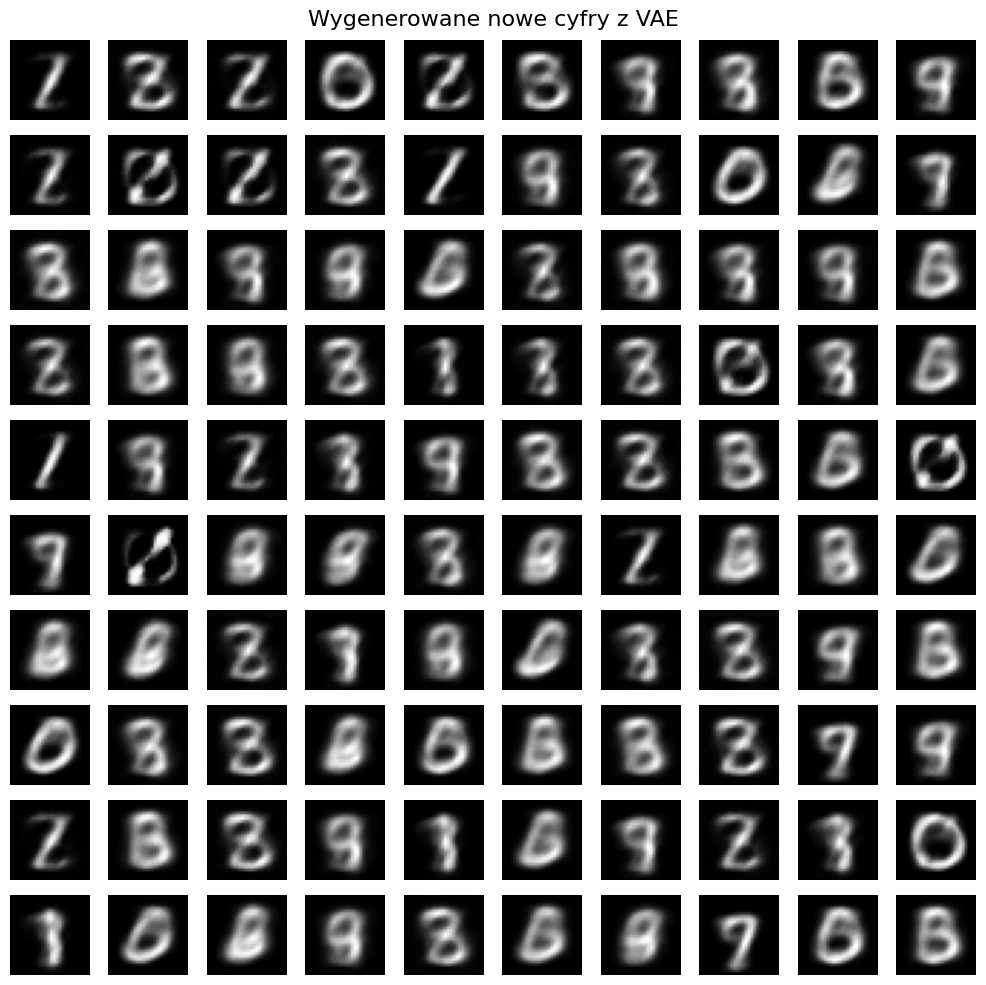

In [ ]:
def generate_new_images(model, device, n_images=100, latent_dim=2):
    """
    Generuj nowe obrazy poprzez próbkowanie z N(0,1) i dekodowanie.

    Args:
        model: Wytrenowany model VAE
        device: Urządzenie do obliczeń
        n_images: Liczba obrazów do wygenerowania
        latent_dim: Wymiarowość przestrzeni latentnej
    """
    model.eval()
    with torch.no_grad():
        # Próbkuj ze standardowego rozkładu normalnego
        z = torch.randn(n_images, latent_dim).to(device)
        # Dekoduj aby otrzymać obrazy
        generated = model.decode(z)

    # Wizualizuj
    fig, axes = plt.subplots(10, 10, figsize=(10, 10))
    for i in range(10):
        for j in range(10):
            idx = i * 10 + j
            axes[i, j].imshow(generated[idx].cpu().squeeze().reshape(28, 28), cmap='gray')
            axes[i, j].axis('off')
    plt.suptitle('Wygenerowane nowe cyfry z VAE', fontsize=16)
    plt.tight_layout()
    plt.show()

# Generujemy 100 nowych obrazów
generate_new_images(model_VAE, device, n_images=100, latent_dim=2)

# Ćwiczenie do samodzielnego wykonania

## Zadanie główne: Conditional VAE (CVAE) - kontrolowane generowanie cyfr

### Cel
Zmodyfikuj model VAE tak, aby mógł generować **konkretne cyfry na żądanie**. Zamiast losować z rozkładu N(0,1) i otrzymywać przypadkową cyfrę, chcemy móc powiedzieć "wygeneruj mi cyfrę 7" i otrzymać realistycznie wyglądającą siódemkę.

### Opis problemu
W zwykłym VAE nie mamy kontroli nad tym, co generujemy. CVAE (Conditional VAE) rozwiązuje ten problem przez **dodanie informacji o etykiecie** (labelce) zarówno do enkodera jak i dekodera.

### Kroki do wykonania:

#### 1. Przygotuj reprezentację etykiet (one-hot encoding)
Etykiety cyfr (0-9) zamień na wektory 10-wymiarowe, np.:
- Cyfra 0 → [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
- Cyfra 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
- Cyfra 7 → [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]

```python
def one_hot_encode(labels, num_classes=10):
    """Konwertuj etykiety na reprezentację one-hot"""
    # Twoja implementacja tutaj
    pass
```

#### 2. Zmodyfikuj architekturę VAE
Musisz dodać etykietę do:
- **Enkodera**: konkatenuj obraz (784 wymiary) z etykietą (10 wymiarów) → wejście ma 794 wymiary
- **Dekodera**: konkatenuj kod latentny z etykietą → dekoder wie, jaką cyfrę ma odtworzyć

```python
class CVAE(nn.Module):
    def __init__(self, latent_space_size=10, num_classes=10):
        super(CVAE, self).__init__()
        # Enkoder: wejście to obraz + etykieta
        self.fc1 = nn.Linear(784 + num_classes, 400)
        self.fc21 = nn.Linear(400, latent_space_size)  # mu
        self.fc22 = nn.Linear(400, latent_space_size)  # logvar
        
        # Dekoder: wejście to kod latentny + etykieta
        self.fc3 = nn.Linear(latent_space_size + num_classes, 400)
        self.fc4 = nn.Linear(400, 784)
        
    def encode(self, x, c):
        """
        Args:
            x: obraz (batch_size, 784)
            c: etykieta one-hot (batch_size, 10)
        """
        # Połącz obraz z etykietą
        # Twoja implementacja
        pass
    
    def decode(self, z, c):
        """
        Args:
            z: kod latentny (batch_size, latent_dim)
            c: etykieta one-hot (batch_size, 10)
        """
        # Połącz kod latentny z etykietą
        # Twoja implementacja
        pass
    
    def forward(self, x, c):
        # Twoja implementacja
        pass
```

#### 3. Zmodyfikuj pętlę treningową
Musisz teraz przekazywać etykiety do modelu:
```python
for batch_idx, (data, labels) in enumerate(train_dataloader):
    data = data.to(device)
    labels_onehot = one_hot_encode(labels).to(device)  # Konwertuj etykiety
    
    recon_batch, mu, logvar = model(data, labels_onehot)  # Przekaż etykiety
    loss, BCE, KLD = vae_loss_function(recon_batch, data, mu, logvar)
    # ... reszta treningu
```

#### 4. Generuj konkretne cyfry
Po wytrenowaniu możesz generować wybrane cyfry:
```python
def generate_specific_digit(model, device, digit, n_samples=10, latent_dim=10):
    """
    Wygeneruj n_samples obrazów konkretnej cyfry
    
    Args:
        model: wytrenowany CVAE
        device: urządzenie
        digit: cyfra do wygenerowania (0-9)
        n_samples: ile obrazów wygenerować
        latent_dim: wymiarowość przestrzeni latentnej
    """
    model.eval()
    with torch.no_grad():
        # Losuj z N(0,1)
        z = torch.randn(n_samples, latent_dim).to(device)
        
        # Stwórz wektor one-hot dla wybranej cyfry
        c = torch.zeros(n_samples, 10).to(device)
        c[:, digit] = 1
        
        # Generuj obrazy
        generated = model.decode(z, c)
    
    # Wizualizuj
    fig, axes = plt.subplots(1, n_samples, figsize=(15, 2))
    for i in range(n_samples):
        axes[i].imshow(generated[i].cpu().squeeze().reshape(28, 28), cmap='gray')
        axes[i].axis('off')
    plt.suptitle(f'Wygenerowane obrazy cyfry {digit}', fontsize=14)
    plt.show()

# Przykłady użycia:
generate_specific_digit(model_cvae, device, digit=0, n_samples=10)
generate_specific_digit(model_cvae, device, digit=7, n_samples=10)
```

#### 5. Wizualizacja przestrzeni latentnej z podziałem na cyfry
Wyciągnij reprezentacje latentne i pokoloruj punkty według cyfr:
```python
mu_list, labels = extract_latent_representations(model_cvae, test_dataloader, device)
# Użyj funkcji plot_latent_space do wizualizacji
```

### Pytania do przemyślenia:
1. Czy separacja cyfr w przestrzeni latentnej jest lepsza niż w zwykłym VAE?
2. Jak wygląda interpolacja między różnymi cyframi (np. 3→8)?
3. Co się stanie jeśli do enkodera podasz cyfrę 5, ale do dekodera powiesz żeby zrekonstruował 3?

---

## Zadania dodatkowe (dla chętnych):

### Zadanie A: Detekcja anomalii z VAE (łatwiejsze)
Wykorzystaj wytrenowany VAE do wykrywania nietypowych cyfr:
1. Oblicz błąd rekonstrukcji dla wszystkich obrazów testowych
2. Znajdź obrazy z największym błędem (potencjalne anomalie)
3. Zwizualizuj je - czy rzeczywiście są nietypowe?

**Wskazówka**: Użyj `F.binary_cross_entropy` per-sample zamiast sum.

### Zadanie B: VAE na Fashion-MNIST (średnie)
Zastosuj poznane techniki do innego zbioru danych:
1. Załaduj Fashion-MNIST (`datasets.FashionMNIST`)
2. Wytrenuj VAE konwolucyjny
3. Porównaj wyniki z MNIST (czy rekonstrukcja jest lepsza/gorsza?)
4. Sprawdź czy różne klasy ubrań są dobrze rozdzielone w przestrzeni latentnej

### Zadanie C: β-VAE - kontrolowana rozdzielczość (trudniejsze)
Zaimplementuj wariant VAE z kontrolowaną wagą KL divergence:
1. Dodaj parametr β (beta) do funkcji straty: `Loss = BCE + β * KLD`
2. Wytrenuj modele z różnymi wartościami β (0.5, 1.0, 2.0, 5.0)
3. Porównaj:
   - Jakość rekonstrukcji
   - Separację w przestrzeni latentnej
   - Jakość generowanych obrazów
4. Zastanów się: jaki β daje najlepszy trade-off?

### Zadanie D: VAE z różnymi rozmiarami przestrzeni latentnej (średnie)
Zbadaj wpływ wymiaru przestrzeni latentnej:
1. Wytrenuj VAE z `latent_dim = [2, 5, 10, 20, 50]`
2. Dla każdego porównaj:
   - Loss treningowy i testowy
   - Jakość rekonstrukcji (wizualnie i liczbowo)
   - Separację cyfr (czy można je rozróżnić?)
3. Który wymiar jest optymalny dla MNIST?

---

## Kryteria oceny samodzielnej pracy:

✅ **Minimalne** (zaliczenie podstawowe):
- CVAE działa i można wytrenować model
- Potrafi generować konkretne cyfry na żądanie
- Kod jest skomentowany

✅✅ **Dobre** (solidna praca):
- Wszystko z poziomu minimum
- Dodana wizualizacja i analiza wyników
- Porównanie z zwykłym VAE
- Przetestowane różne hiperparametry

✅✅✅ **Bardzo dobre** (głęboka analiza):
- Wszystko z poprzednich poziomów
- Wykonane jedno lub więcej zadań dodatkowych
- Przemyślana analiza z wnioskami
- Eksperymentowanie z architekturą

---

## Przydatne funkcje PyTorch:

```python
# One-hot encoding
torch.nn.functional.one_hot(labels, num_classes=10)

# Konkatenacja tensorów
torch.cat([tensor1, tensor2], dim=1)

# Konwersja etykiet na tensor
labels = torch.LongTensor(labels)
```

Powodzenia! 🚀

# Podsumowanie i porównanie metod

W tym notebooku przeszliśmy przez różne metody redukcji wymiarowości i reprezentacji danych MNIST:

## Porównanie metod:

| Metoda | Typ | Wymiarowość latentna | Rekonstrukcja | Generowanie | Struktura przestrzeni |
|--------|-----|---------------------|---------------|-------------|----------------------|
| **PCA** | Liniowa | Dowolna |  Nie |  Nie | Liniowa, zachowuje wariancję |
| **UMAP** | Nieliniowa | 2-3 (wizualizacja) |  Nie | Nie | Zachowuje lokalną i globalną strukturę |
| **Autoencoder** | Nieliniowa | Dowolna | Tak |  Ograniczone | Może mieć "dziury", nieciągła |
| **VAE** | Probabilistyczna | Dowolna | Tak | Tak | Gładka, ciągła, probabilistyczna |
| **VAE + Conv** | Probabilistyczna + CNN | Dowolna | Najlepsza | Tak | Jak VAE, lepsza jakość |

## Kluczowe wnioski:

### 1. PCA i UMAP - metody eksploracyjne
- **PCA**: Szybka, prosta, liniowa. Dobra do pierwszej analizy danych.
- **UMAP**: Lepsza wizualizacja, zachowuje strukturę klastrów, ale tylko do wizualizacji.

### 2. Autoencoder - kompresja i rekonstrukcja
- **Zalety**: Nieliniowa redukcja, dobra rekonstrukcja
- **Wady**: Przestrzeń latentna może być nieciągła, trudno generować nowe przykłady
- **Zastosowania**: Kompresja, denoising, detekcja anomalii

### 3. VAE - modelowanie generatywne
- **Zalety**:
  - Gładka, ciągła przestrzeń latentna
  - Generowanie nowych przykładów
  - Interpolacja między punktami
  - Interpretowalna struktura probabilistyczna
- **Wady**:
  - Rekonstrukcja może być nieco gorsza niż w AE (trade-off z regularyzacją)
  - Bardziej skomplikowana implementacja
- **Zastosowania**: Generowanie danych, semi-supervised learning, transfer learning

### 4. Architektura konwolucyjna
- Znacznie lepsza jakość dla danych obrazowych
- Mniej parametrów przy lepszej wydajności
- Wykorzystuje przestrzenną strukturę obrazów

## Co dalej?

Po opanowaniu tych materiałów możesz:
- Eksperymentować z różnymi architekturami (głębsze sieci, ResNet w VAE)
- Zastosować VAE do bardziej złożonych danych (CelebA, ImageNet)
- Poznać nowsze warianty: β-VAE, Conditional VAE (CVAE), VQ-VAE
- Przejść do Generative Adversarial Networks (GANs)
- Zapoznać się z Diffusion Models (state-of-the-art w generowaniu obrazów)

## Dodatkowe zasoby:

- Oryginalny paper VAE: [Auto-Encoding Variational Bayes (Kingma & Welling, 2013)](https://arxiv.org/abs/1312.6114)
- Tutorial VAE: [Understanding VAEs](https://arxiv.org/abs/1606.05908)
- Implementacje: https://github.com/AntixK/PyTorch-VAE